<a href="https://colab.research.google.com/github/vellysiazhrn/Music-Genre-Classification-CNN-Bi-GRU/blob/main/Music_Genre_Classification_Vellysia_3043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import os
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [42]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT     = "/content/drive/MyDrive/SPEECHPRO/Program/Data"
DATASET_PATH  = f"{DATA_ROOT}/genres_original"
CACHE_DIR     = "/content/drive/MyDrive/SPEECHPRO/Program/cache"  # simpan fitur agar tidak ekstrak ulang
os.makedirs(CACHE_DIR, exist_ok=True)

genres = sorted([g for g in os.listdir(DATASET_PATH) if os.path.isdir(f'{DATASET_PATH}/{g}')])
print('Genre terdeteksi:', genres)
print('Jumlah genre   :', len(genres))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Genre terdeteksi: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Jumlah genre   : 10


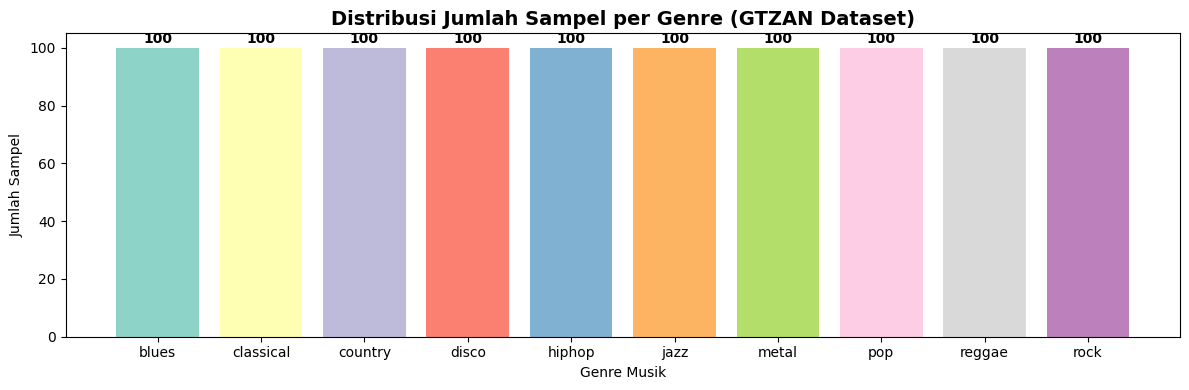

In [43]:
# Visualisasi distribusi dataset
genre_counts = {g: len(list(Path(f'{DATASET_PATH}/{g}').glob('*.wav'))) for g in genres}

plt.figure(figsize=(12, 4))
bars = plt.bar(genre_counts.keys(), genre_counts.values(), color=plt.cm.Set3(range(len(genres))))
plt.title('Distribusi Jumlah Sampel per Genre (GTZAN Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Genre Musik')
plt.ylabel('Jumlah Sampel')
for bar, count in zip(bars, genre_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/distribusi_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

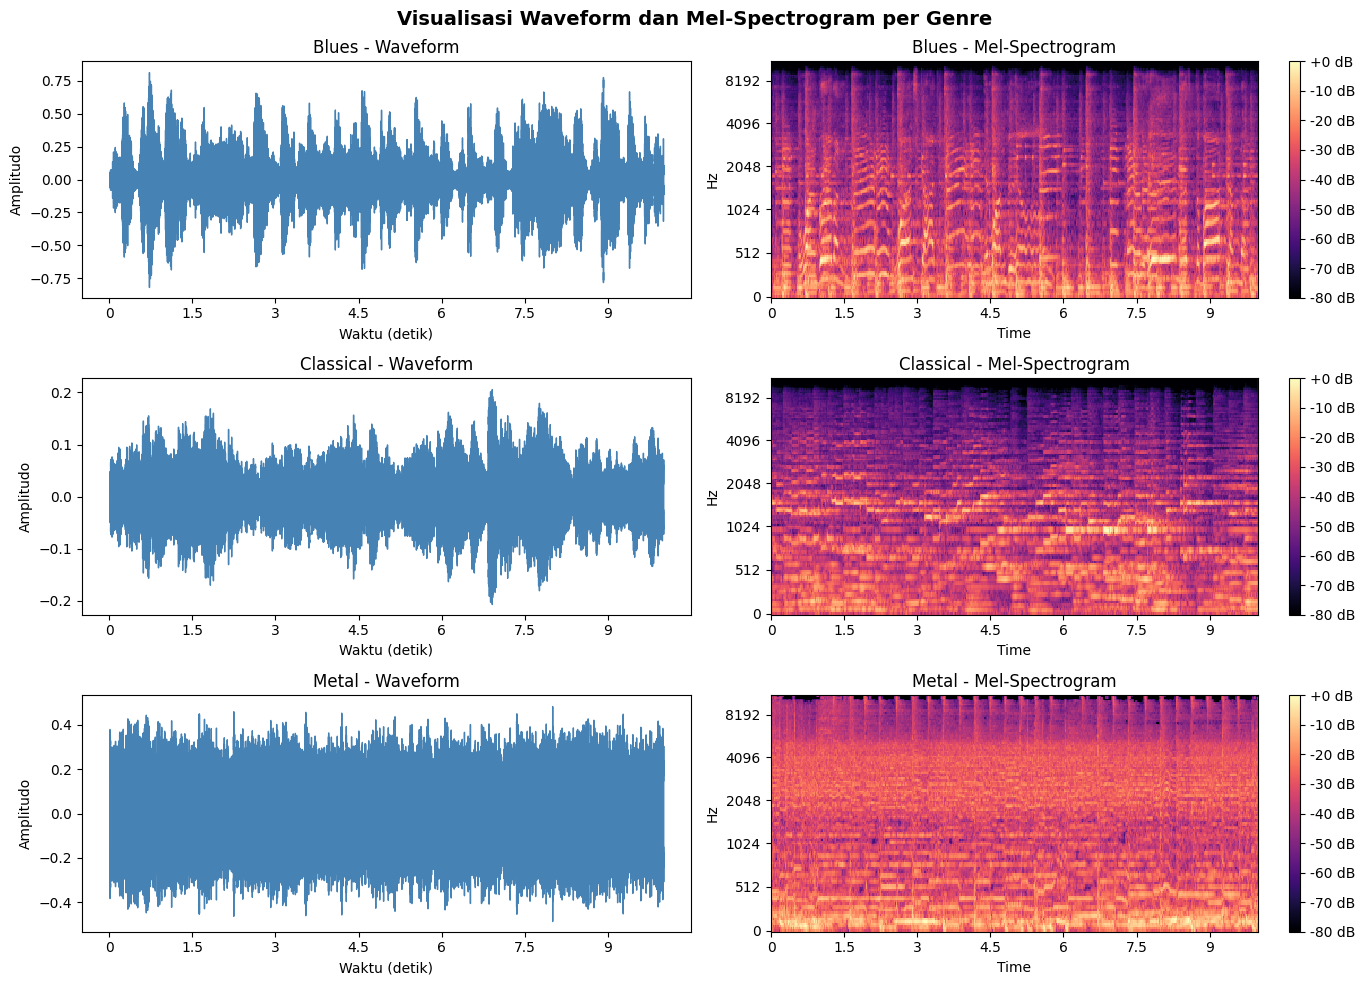

In [44]:
# Visualisasi waveform + Mel-Spectrogram untuk 3 genre berbeda
sample_genres = ['blues', 'classical', 'metal']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Visualisasi Waveform dan Mel-Spectrogram per Genre', fontsize=14, fontweight='bold')

for i, genre in enumerate(sample_genres):
    audio_path = f'{DATASET_PATH}/{genre}/{genre}.00000.wav'
    y, sr = librosa.load(audio_path, duration=10)

    axes[i, 0].set_title(f'{genre.capitalize()} - Waveform')
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_xlabel('Waktu (detik)')
    axes[i, 0].set_ylabel('Amplitudo')

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                    x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'{genre.capitalize()} - Mel-Spectrogram')
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('/content/visualisasi_mel_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Parameter ekstraksi fitur (sesuai paper Ashraf et al. 2023)
SAMPLE_RATE   = 22050
DURATION      = 3       # detik per segmen
OVERLAP       = 0.5     # 50% overlap
N_FFT         = 1024
HOP_LENGTH    = 512
N_MELS        = 128
TARGET_SHAPE  = (128, 128)   # (mel_bins, time_frames)

SAMPLES_PER_SEGMENT = int(SAMPLE_RATE * DURATION)
HOP_SAMPLES = int(SAMPLES_PER_SEGMENT * (1 - OVERLAP))

print('Parameter Ekstraksi Fitur:')
print(f'  Sample rate     : {SAMPLE_RATE} Hz')
print(f'  Durasi segmen   : {DURATION} detik')
print(f'  Overlap         : {OVERLAP*100:.0f}%')
print(f'  N_FFT           : {N_FFT}')
print(f'  Hop length      : {HOP_LENGTH}')
print(f'  Mel bands       : {N_MELS}')
print(f'  Target shape    : {TARGET_SHAPE}')


Parameter Ekstraksi Fitur:
  Sample rate     : 22050 Hz
  Durasi segmen   : 3 detik
  Overlap         : 50%
  N_FFT           : 1024
  Hop length      : 512
  Mel bands       : 128
  Target shape    : (128, 128)


In [46]:
def extract_mel_segments(file_path, genre_label, track_id):
    segments_data = []
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        total_samples = len(y)
        if total_samples < SAMPLES_PER_SEGMENT:
            return segments_data
        start = 0
        while start + SAMPLES_PER_SEGMENT <= total_samples:
            segment = y[start : start + SAMPLES_PER_SEGMENT]
            mel = librosa.feature.melspectrogram(
                y=segment, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
            )
            mel_db = librosa.power_to_db(mel, ref=np.max)
            if mel_db.shape[1] >= TARGET_SHAPE[1]:
                mel_db = mel_db[:, :TARGET_SHAPE[1]]
            else:
                mel_db = np.pad(mel_db, ((0,0),(0, TARGET_SHAPE[1]-mel_db.shape[1])))
            segments_data.append((mel_db, genre_label, track_id))
            start += HOP_SAMPLES
    except Exception as e:
        print(f'  [SKIP] {file_path}: {e}')
    return segments_data

In [47]:
# Ekstraksi fitur untuk semua genre (dengan caching)
CACHE_X     = f'{CACHE_DIR}/X_features.npy'
CACHE_Y     = f'{CACHE_DIR}/y_labels.npy'
CACHE_TRACK = f'{CACHE_DIR}/track_ids.npy'

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y) and os.path.exists(CACHE_TRACK):
    X_raw      = np.load(CACHE_X)
    all_labels = np.load(CACHE_Y, allow_pickle=True)
    track_ids  = np.load(CACHE_TRACK, allow_pickle=True)
    print(f'Cache : X={X_raw.shape}, labels={all_labels.shape}, tracks={track_ids.shape}')
else:
    all_features = []
    all_labels_l = []
    track_ids_l  = []

    for genre in genres:
        genre_path = Path(DATASET_PATH) / genre
        audio_files = sorted(genre_path.glob('*.wav'))
        count = 0
        skipped = 0
        for audio_file in audio_files:
            segments = extract_mel_segments(str(audio_file), genre, audio_file.stem)
            if not segments:
                skipped += 1
                continue
            for feat, label, tid in segments:
                all_features.append(feat)
                all_labels_l.append(label)
                track_ids_l.append(tid)
            count += len(segments)
        print(f'{genre:10s}: {len(audio_files)} file ({skipped} dilewati) -> {count} segmen')

    X_raw      = np.array(all_features, dtype=np.float32)
    all_labels = np.array(all_labels_l)
    track_ids  = np.array(track_ids_l)

    np.save(CACHE_X, X_raw)
    np.save(CACHE_Y, all_labels)
    np.save(CACHE_TRACK, track_ids)

print(f'\nTotal segmen: {X_raw.shape[0]}')


blues     : 100 file (0 dilewati) -> 1900 segmen
classical : 100 file (0 dilewati) -> 1898 segmen
country   : 100 file (0 dilewati) -> 1897 segmen
disco     : 100 file (0 dilewati) -> 1899 segmen
hiphop    : 100 file (0 dilewati) -> 1898 segmen


/tmp/ipykernel_2314/168399791.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [SKIP] /content/drive/MyDrive/SPEECHPRO/Program/Data/genres_original/jazz/jazz.00054.wav: 
jazz      : 100 file (1 dilewati) -> 1881 segmen
metal     : 100 file (0 dilewati) -> 1900 segmen
pop       : 100 file (0 dilewati) -> 1900 segmen
reggae    : 100 file (0 dilewati) -> 1900 segmen
rock      : 100 file (0 dilewati) -> 1899 segmen

Total segmen: 18972


In [48]:
# Tambah channel dimension: (N, 128, 128, 1)
X = X_raw[..., np.newaxis]

# Normalisasi ke distribusi standar (zero mean, unit variance)
X_mean = X.mean()
X_std  = X.std()
X = (X - X_mean) / (X_std + 1e-8)

# Label encoding
le = LabelEncoder()
y_enc = le.fit_transform(all_labels)
y_cat = to_categorical(y_enc, num_classes=len(genres))

print(f'Shape X (fitur)   : {X.shape}  -> (N_sampel, mel_bins, time_frames, channel)')
print(f'Shape y (label)   : {y_cat.shape}')
print(f'Genre encoding    : {dict(zip(le.classes_, range(len(le.classes_))))}')
print(f'Min/Max nilai X   : {X.min():.2f} / {X.max():.2f}')


Shape X (fitur)   : (18972, 128, 128, 1)  -> (N_sampel, mel_bins, time_frames, channel)
Shape y (label)   : (18972, 10)
Genre encoding    : {np.str_('blues'): 0, np.str_('classical'): 1, np.str_('country'): 2, np.str_('disco'): 3, np.str_('hiphop'): 4, np.str_('jazz'): 5, np.str_('metal'): 6, np.str_('pop'): 7, np.str_('reggae'): 8, np.str_('rock'): 9}
Min/Max nilai X   : -2.51 / 2.65


In [49]:
unique_tracks = np.unique(track_ids)
track_genre = {t: all_labels[track_ids == t][0] for t in unique_tracks}

# Stratified split berdasarkan genre tiap track
tracks_train, tracks_temp = train_test_split(
    unique_tracks, test_size=0.2, random_state=42,
    stratify=[track_genre[t] for t in unique_tracks]
)
tracks_val, tracks_test = train_test_split(
    tracks_temp, test_size=0.5, random_state=42,
    stratify=[track_genre[t] for t in tracks_temp]
)

train_mask = np.isin(track_ids, tracks_train)
val_mask   = np.isin(track_ids, tracks_val)
test_mask  = np.isin(track_ids, tracks_test)

X_train, y_train = X[train_mask], y_cat[train_mask]
X_val,   y_val   = X[val_mask],   y_cat[val_mask]
X_test,  y_test  = X[test_mask],  y_cat[test_mask]

print(f'Train set  : {X_train.shape[0]} segmen dari {len(tracks_train)} track')
print(f'Val set    : {X_val.shape[0]} segmen dari {len(tracks_val)} track')
print(f'Test set   : {X_test.shape[0]} segmen dari {len(tracks_test)} track')


Train set  : 15172 segmen dari 799 track
Val set    : 1900 segmen dari 100 track
Test set   : 1900 segmen dari 100 track


In [50]:
def spec_augment(mel, freq_mask_param=12, time_mask_param=12, n_masks=1):
    mel = mel.copy()
    n_mels, n_frames = mel.shape[0], mel.shape[1]
    for _ in range(n_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(1, n_mels - f))
        mel[f0:f0+f, :, :] = 0.0

        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(1, n_frames - t))
        mel[:, t0:t0+t, :] = 0.0
    return mel


class AugmentedDataGenerator(keras.utils.Sequence):
    def __init__(self, X, y, batch_size=64, augment=True, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx]
        if self.augment:
            for i in range(len(X_batch)):
                if np.random.rand() < 0.5:
                    X_batch[i] = spec_augment(X_batch[i])
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 64
train_gen = AugmentedDataGenerator(X_train, y_train, batch_size=BATCH_SIZE, augment=True, shuffle=True)
val_gen   = AugmentedDataGenerator(X_val, y_val, batch_size=BATCH_SIZE, augment=False, shuffle=False)

In [51]:
def build_cnn_bigru_model(input_shape=(128, 128, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='mel_spectrogram_input')

    x = inputs
    for i in range(1, 6):
        x = layers.Conv2D(128, (5, 5), padding='same', activation='relu', name=f'conv{i}')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2), name=f'pool{i}')(x)
        x = layers.Dropout(0.25, name=f'drop{i}')(x)

    # Reshape untuk Bi-GRU: (batch, freq, time, filters) -> (batch, time, freq*filters)
    shape = x.shape
    x = layers.Reshape((shape[2], shape[1] * shape[3]), name='reshape_for_rnn')(x)

    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True, dropout=0.25), name='bigru1'
    )(x)
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True, dropout=0.25), name='bigru2'
    )(x)
    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=False, dropout=0.25), name='bigru3'
    )(x)

    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='output')(x)

    model = Model(inputs, outputs, name='CNN_BiGRU_MusicGenre')
    return model


model = build_cnn_bigru_model(input_shape=(128, 128, 1), num_classes=len(genres))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "CNN_BiGRU_MusicGenre"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram_input           │ (None, 128, 128, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 128)  │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_for_rnn (Reshape)       │ (None, 4, 512)         │             

 Total params: 2,575,754 (9.83 MB)

 Trainable params: 2,574,474 (9.82 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [52]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        '/content/best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=80,
    callbacks=callbacks,
    verbose=1
)

best_val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_acc*100:.2f}%')


Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


238/238 ━━━━━━━━━━━━━━━━━━━━ 101s 376ms/step - accuracy: 0.4468 - loss: 1.5104 - val_accuracy: 0.1016 - val_loss: 5.2145 - learning_rate: 0.0010
Epoch 2/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 89s 373ms/step - accuracy: 0.6474 - loss: 1.0093 - val_accuracy: 0.5811 - val_loss: 1.3793 - learning_rate: 0.0010
Epoch 3/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 88s 370ms/step - accuracy: 0.7422 - loss: 0.7642 - val_accuracy: 0.5589 - val_loss: 1.6457 - learning_rate: 0.0010
Epoch 4/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 88s 371ms/step - accuracy: 0.7934 - loss: 0.6309 - val_accuracy: 0.6763 - val_loss: 1.2076 - learning_rate: 0.0010
Epoch 5/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 88s 371ms/step - accuracy: 0.8213 - loss: 0.5368 - val_accuracy: 0.7295 - val_loss: 1.0396 - learning_rate: 0.0010
Epoch 6/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 88s 371ms/step - accuracy: 0.8516 - loss: 0.4559 - val_accuracy: 0.6995 - val_loss: 1.0970 - learning_rate: 0.0010
Epoch 7/80
238/238 ━━━━━━━━━━━━━━━━━━━━ 88s 370ms/step - accuracy: 0.8798 - loss

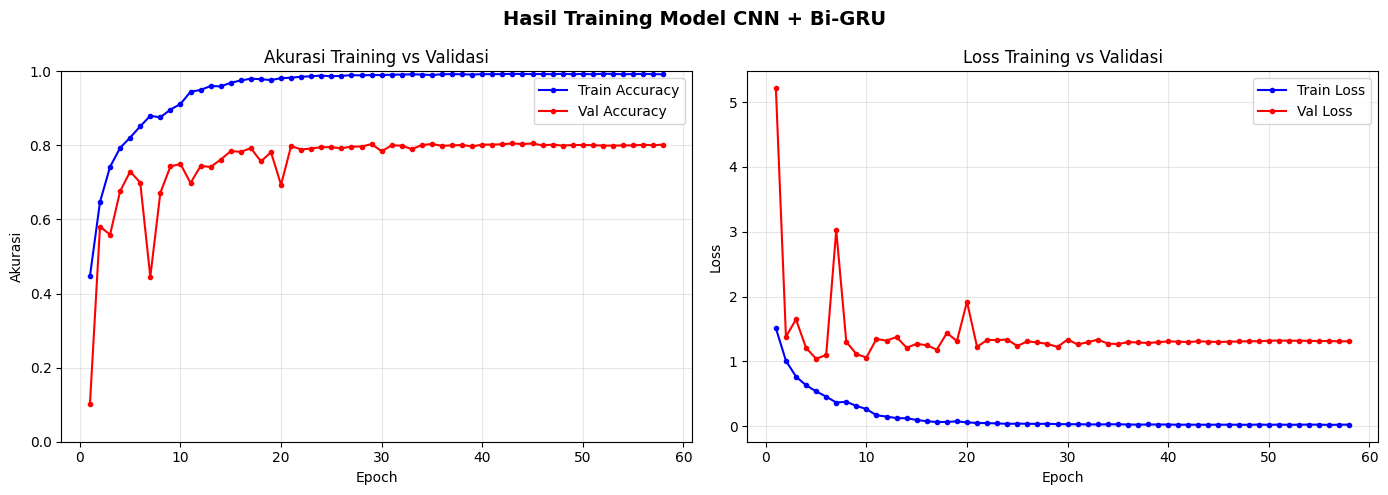

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hasil Training Model CNN + Bi-GRU', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_range, history.history['accuracy'], 'b-o', markersize=3, label='Train Accuracy')
ax1.plot(epochs_range, history.history['val_accuracy'], 'r-o', markersize=3, label='Val Accuracy')
ax1.set_title('Akurasi Training vs Validasi')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Akurasi')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

ax2.plot(epochs_range, history.history['loss'], 'b-o', markersize=3, label='Train Loss')
ax2.plot(epochs_range, history.history['val_loss'], 'r-o', markersize=3, label='Val Loss')
ax2.set_title('Loss Training vs Validasi')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print('='*60)
print(classification_report(y_true, y_pred, target_names=le.classes_))

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print('\nMETRIK PER-SEGMEN:')
print(f'  Akurasi   : {acc*100:.2f}%')
print(f'  Presisi   : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')

Test Accuracy : 80.32%
Test Loss     : 1.2356

Classification Report:
              precision    recall  f1-score   support

       blues       0.96      0.79      0.87       190
   classical       0.97      0.92      0.94       190
     country       0.73      0.83      0.78       190
       disco       0.72      0.64      0.68       190
      hiphop       0.74      0.91      0.81       190
        jazz       0.86      0.92      0.89       190
       metal       0.94      0.89      0.92       190
         pop       0.69      0.73      0.71       190
      reggae       0.86      0.71      0.78       190
        rock       0.65      0.69      0.67       190

    accuracy                           0.80      1900
   macro avg       0.81      0.80      0.80      1900
weighted avg       0.81      0.80      0.80      1900


METRIK PER-SEGMEN:
  Akurasi   : 80.32%
  Presisi   : 81.17%
  Recall    : 80.32%
  F1-Score  : 80.41%


In [55]:
test_track_ids = track_ids[test_mask]

track_true = {}
track_prob_sum = {}

for i, tid in enumerate(test_track_ids):
    if tid not in track_prob_sum:
        track_prob_sum[tid] = np.zeros(len(genres))
        track_true[tid] = y_true[i]
    track_prob_sum[tid] += y_pred_prob[i]

track_ids_list = list(track_prob_sum.keys())
y_true_track = np.array([track_true[t] for t in track_ids_list])
y_pred_track = np.array([np.argmax(track_prob_sum[t]) for t in track_ids_list])

acc_track  = accuracy_score(y_true_track, y_pred_track)
prec_track = precision_score(y_true_track, y_pred_track, average='weighted')
rec_track  = recall_score(y_true_track, y_pred_track, average='weighted')
f1_track   = f1_score(y_true_track, y_pred_track, average='weighted')

print(f'Jumlah track di test set: {len(track_ids_list)}')
print(classification_report(y_true_track, y_pred_track, target_names=le.classes_))

print('\nPERBANDINGAN: per-segmen vs per-track (ensemble)')
print(f'  Akurasi per-segmen : {acc*100:.2f}%')
print(f'  Akurasi per-track  : {acc_track*100:.2f}%  (selisih: {(acc_track-acc)*100:+.2f}%)')
print(f'  Presisi  per-track : {prec_track*100:.2f}%')
print(f'  Recall   per-track : {rec_track*100:.2f}%')
print(f'  F1-Score per-track : {f1_track*100:.2f}%')


Jumlah track di test set: 100
              precision    recall  f1-score   support

       blues       1.00      0.90      0.95        10
   classical       1.00      1.00      1.00        10
     country       0.83      1.00      0.91        10
       disco       0.78      0.70      0.74        10
      hiphop       0.75      0.90      0.82        10
        jazz       1.00      1.00      1.00        10
       metal       0.91      1.00      0.95        10
         pop       0.73      0.80      0.76        10
      reggae       1.00      0.80      0.89        10
        rock       1.00      0.80      0.89        10

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100


PERBANDINGAN: per-segmen vs per-track (ensemble)
  Akurasi per-segmen : 80.32%
  Akurasi per-track  : 89.00%  (selisih: +8.68%)
  Presisi  per-track : 89.97%
  Recall   per-track : 89.00%
  F1-Score per-track :

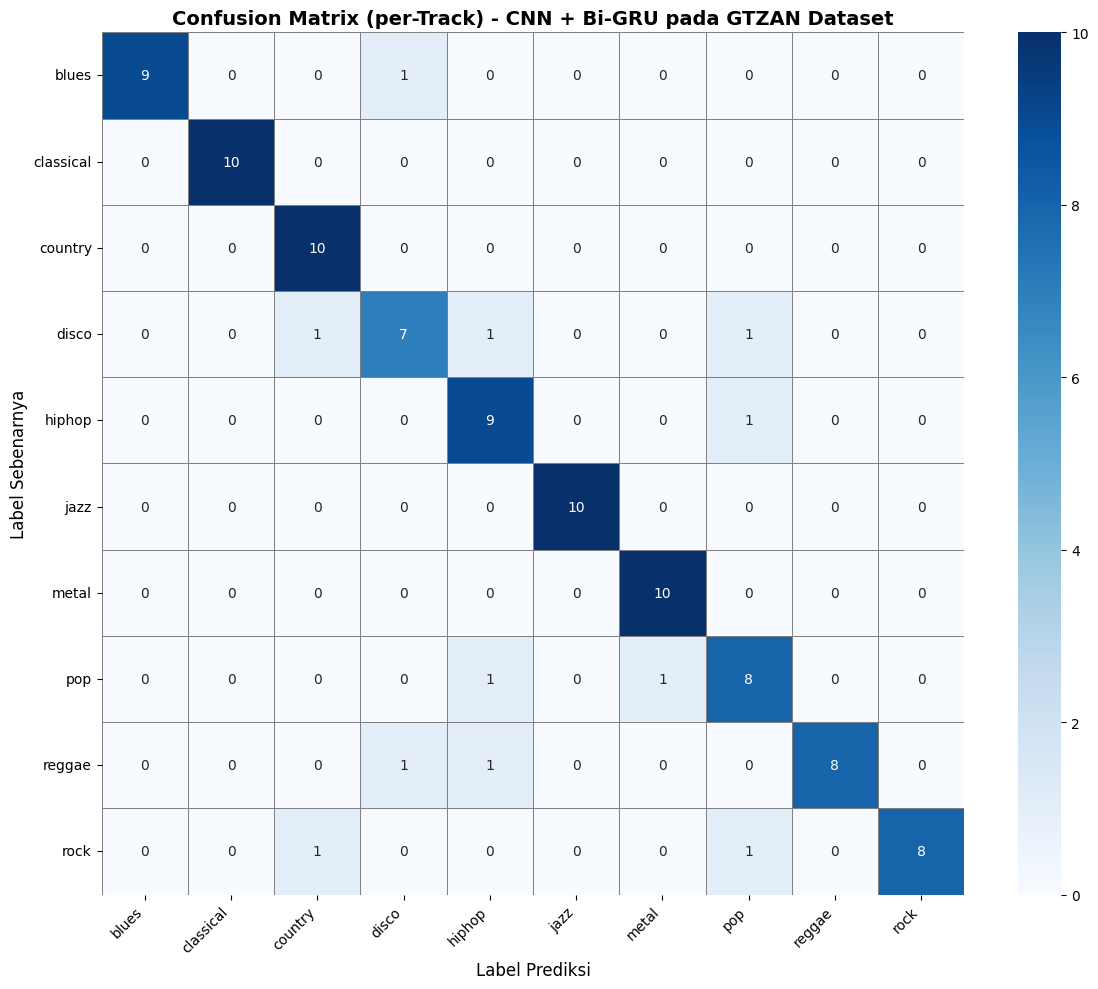

In [56]:
# Confusion matrix dihitung dari hasil ensemble per-track (lebih representatif)
cm = confusion_matrix(y_true_track, y_pred_track)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor='gray'
)
plt.title('Confusion Matrix (per-Track) - CNN + Bi-GRU pada GTZAN Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=12)
plt.xlabel('Label Prediksi', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

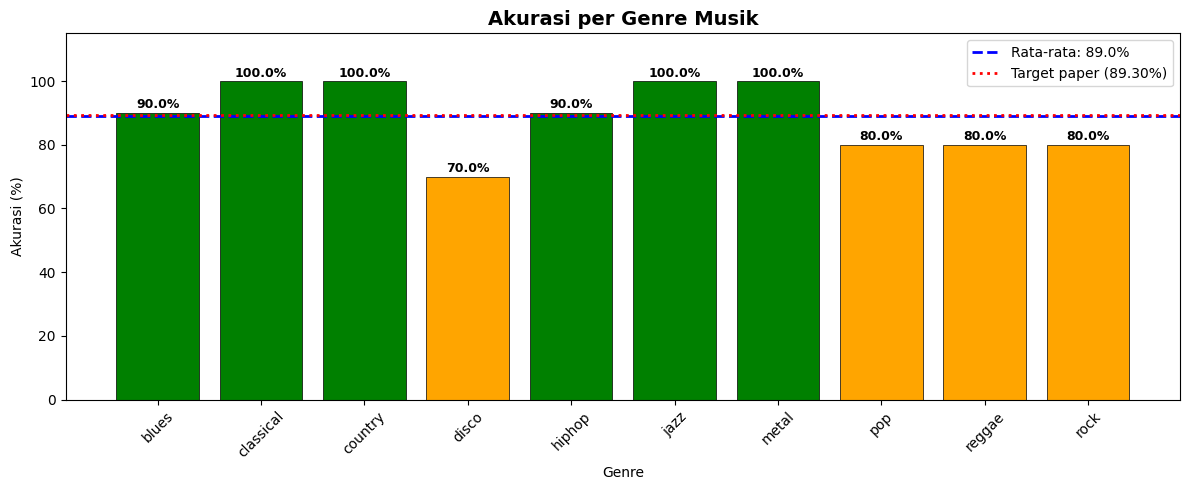

In [57]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
colors = ['green' if a >= 0.85 else 'orange' if a >= 0.70 else 'red' for a in per_class_acc]
bars = plt.bar(le.classes_, per_class_acc * 100, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=np.mean(per_class_acc)*100, color='blue', linestyle='--', linewidth=2,
            label=f'Rata-rata: {np.mean(per_class_acc)*100:.1f}%')
plt.axhline(y=89.30, color='red', linestyle=':', linewidth=2,
            label='Target paper (89.30%)')
for bar, acc_val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{acc_val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('Akurasi per Genre Musik', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Akurasi (%)')
plt.ylim([0, 115])
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/akurasi_per_genre.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
model.save('/content/model_cnn_bigru_gtzan.keras')

hist_df = pd.DataFrame(history.history)
hist_df.to_csv('/content/training_history.csv', index=False)

results = {
    'test_accuracy_per_segment': float(acc),
    'test_precision_per_segment': float(prec),
    'test_recall_per_segment': float(rec),
    'test_f1_per_segment': float(f1),
    'test_loss': float(test_loss),
    'test_accuracy_per_track': float(acc_track),
    'test_precision_per_track': float(prec_track),
    'test_recall_per_track': float(rec_track),
    'test_f1_per_track': float(f1_track),
    'paper_target': 0.8930,
    'genres': list(le.classes_),
    'per_class_accuracy': {g: float(a) for g, a in zip(le.classes_, per_class_acc)},
    'split_strategy': 'per_track_stratified'
}
with open('/content/hasil_evaluasi.json', 'w') as f:
    json.dump(results, f, indent=2)

In [59]:
from google.colab import files

output_files = [
    '/content/distribusi_dataset.png',
    '/content/visualisasi_mel_spectrogram.png',
    '/content/training_history.png',
    '/content/confusion_matrix.png',
    '/content/akurasi_per_genre.png',
    '/content/training_history.csv',
    '/content/hasil_evaluasi.json',
    '/content/best_model.keras'
]

for f_path in output_files:
    if os.path.exists(f_path):
        files.download(f_path)
        print(f'  OK: {os.path.basename(f_path)}')
    else:
        print(f'  Tidak ditemukan: {f_path}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: distribusi_dataset.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  OK: hasil_evaluasi.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: best_model.keras
